<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
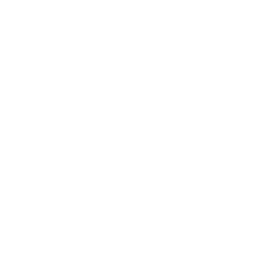
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Codificação de Eventos Adversos em Ensaio Clínico</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmacêutica / Vigilância de Segurança de Medicamentos &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Os conjuntos de dados de eventos adversos chegam com termos preferidos MedDRA
verbatim, mas as tabelas de segurança regulatórias são organizadas por Classe
de Sistema Orgânico (SOC). Este exemplo constrói um formato de valor PROC
FORMAT que mapeia cada termo preferido à sua SOC, e então usa esse único
formato para conduzir toda a tabulação subsequente: um cruzamento PROC FREQ
de SOC por braço de tratamento, uma repartição de SOC por gravidade, e um
resumo de EA graves. Como o mapeamento reside apenas no formato, recodificar
o ensaio para uma nova versão do MedDRA é uma edição de um único formato, em
vez de reescrever cada relatório. O ODS OUTPUT captura as frequências de SOC
como um conjunto de dados para revisão de sinais subsequente.

## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|--------:|
| WORK.AE_RAW | Registros sintéticos de eventos adversos com termos preferidos MedDRA | 100 |
| WORK.RANDOMIZATION | Atribuições de braço de tratamento dos sujeitos | 100 |

O ambiente é executado sem licença, portanto cada tabela gerada é limitada a
100 observações. O cenário é dimensionado para esse limite: 100 eventos
adversos extraídos de um painel MedDRA de 12 termos, típico de um ensaio
oncológico.

---

In [1]:
/* --------------------------------------------------------
   Gerar conjunto de dados sintético de eventos adversos
   Termos preferidos MedDRA mapeados para categorias SOC
   -------------------------------------------------------- */
DADOS work.ae_raw;
    COMPRIMENTO aedecod $40;
    CHAMAR streaminit(42);
    VETOR pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    VETOR sev_list[3] $10 _temporary_ ('LEVE' 'MODERADA' 'GRAVE');
    FAZER i = 1 ATÉ 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', PUT(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        SE pt_idx = 1 ENTÃO aedecod = 'Náusea';
        SENÃO SE pt_idx = 2 ENTÃO aedecod = 'Dor de Cabeça';
        SENÃO SE pt_idx = 3 ENTÃO aedecod = 'Vômito';
        SENÃO SE pt_idx = 4 ENTÃO aedecod = 'Diarreia';
        SENÃO SE pt_idx = 5 ENTÃO aedecod = 'Tosse';
        SENÃO SE pt_idx = 6 ENTÃO aedecod = 'Fadiga';
        SENÃO SE pt_idx = 7 ENTÃO aedecod = 'Artralgia';
        SENÃO SE pt_idx = 8 ENTÃO aedecod = 'Pirexia';
        SENÃO SE pt_idx = 9 ENTÃO aedecod = 'Dor Abdominal';
        SENÃO SE pt_idx = 10 ENTÃO aedecod = 'Neutropenia';
        SENÃO SE pt_idx = 11 ENTÃO aedecod = 'Neutropenia Febril';
        SENÃO SE pt_idx = 12 ENTÃO aedecod = 'Reação Relacionada à Infusão';
        sev_idx = int(rand('uniform') * 3) + 1;
        SE pt_idx IN (10, 11) ENTÃO sev_idx = MAX(sev_idx, 2);
        aesev = sev_list[sev_idx];
        aeser = ifc(aesev = 'GRAVE' E_LÓGICO rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        SE aestdy > 365 ENTÃO aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', PUT(int(rand('uniform') * 25) + 1, z3.));
        SAÍDA;
    FIM;
    REMOVER i pt_idx sev_idx;
EXECUTAR;


NOTE: DATA work.ae_raw

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.83 seconds
  cpu   1.83 seconds


In [2]:
/* --------------------------------------------------------
   Gerar tabela de randomização dos sujeitos
   -------------------------------------------------------- */
DADOS work.randomization;
    CHAMAR streaminit(43);
    VETOR arms[3] $20 _temporary_ ('INVESTIGACIONAL' 'COMPARADOR_ATIVO' 'PLACEBO');
    FAZER subject_id = 1 ATÉ 800;
        usubjid = cat('ONC-2025-', PUT(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        treatment_arm = arms[arm_idx];
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        SAÍDA;
    FIM;
    REMOVER arm_idx;
    FORMATO randomization_date date9.;
EXECUTAR;


NOTE: DATA work.randomization

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.08 seconds
  cpu   0.08 seconds


---

                                  Frequência Bruta de Termos Preferidos (Não Mapeados)                                  

                                                   The FREQ Procedure

Termo Preferido                     Frequency    Percent
---------------------------------------------------------
Diarreia                                   12     12.00
Dor de Cabeça                              12     12.00
Fadiga                                     11     11.00
Pirexia                                    11     11.00
Artralgia                                  10     10.00
Náusea                                     10     10.00
Reação Relacionada à Infusão                8      8.00
Tosse                                       7      7.00
Dor Abdominal                               5      5.00
Neutropenia                                 5      5.00
Neutropenia Febril                          5      5.00
Vômito                                      4      4.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


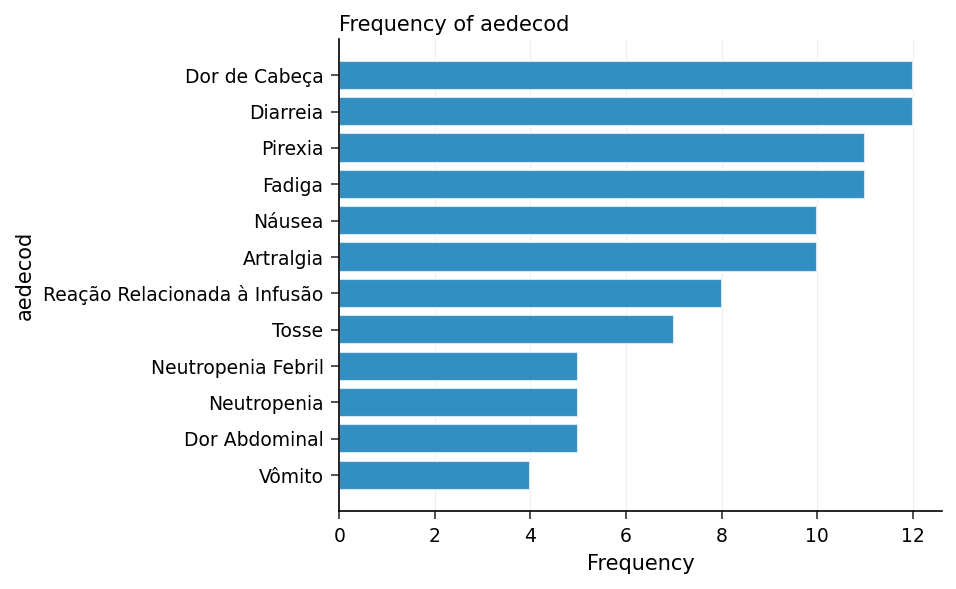

In [3]:
/* --------------------------------------------------------
   Frequência do termo preferido antes do mapeamento SOC
   -------------------------------------------------------- */
PROCEDIMENTO FREQUÊNCIAS DADOS=work.ae_raw ORDER=FREQUÊNCIAS;
    TABLES aedecod / nocum;
    RÓTULO aedecod = 'Termo Preferido';
    TÍTULO 'Frequência Bruta de Termos Preferidos (Não Mapeados)';
EXECUTAR;

---

                                  Frequência Bruta de Termos Preferidos (Não Mapeados)                                  




NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


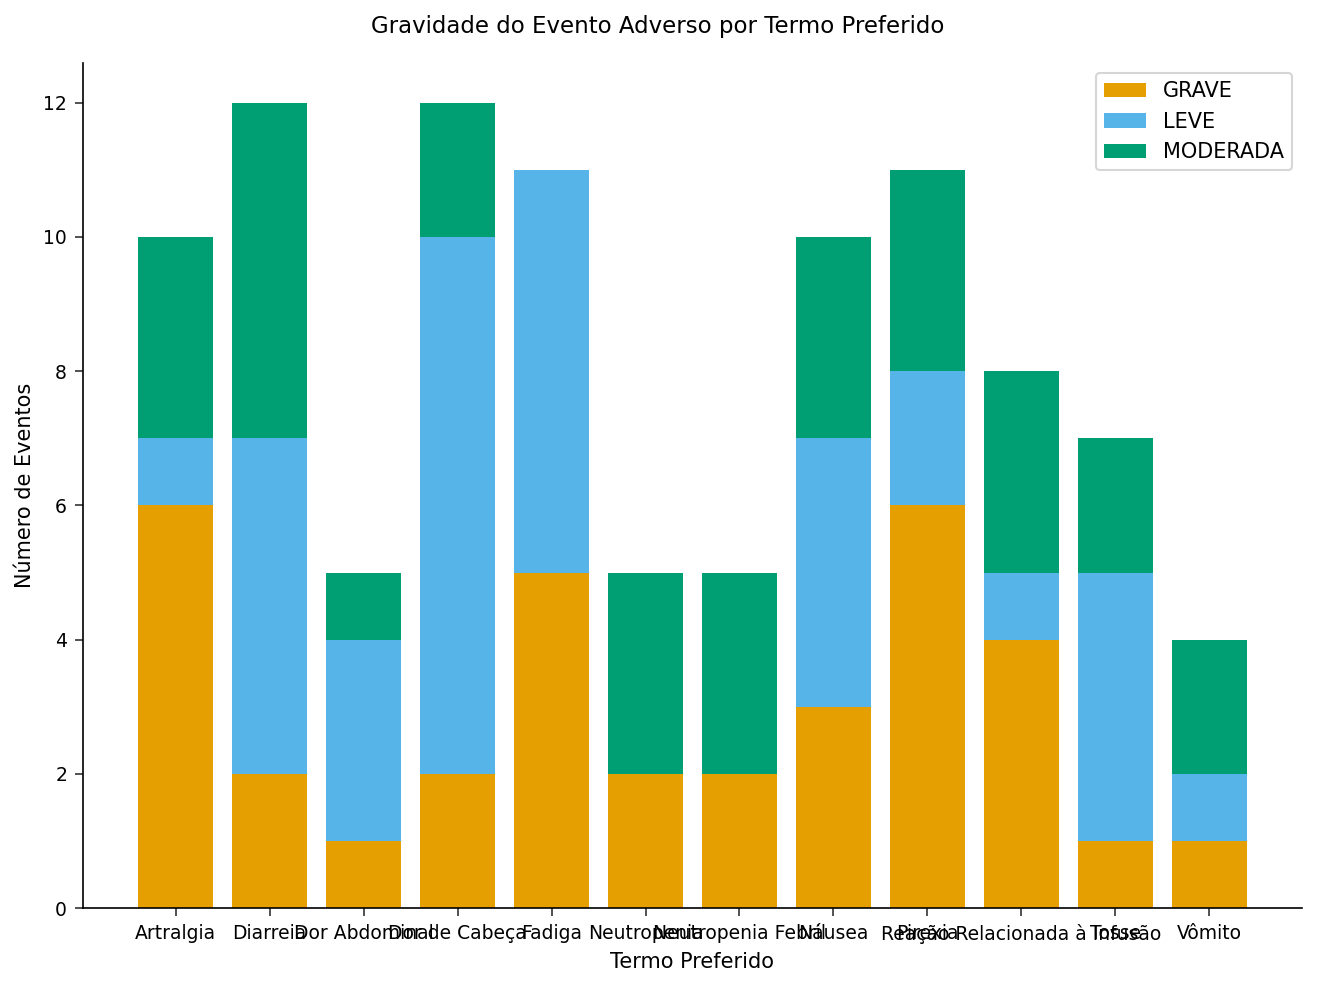

In [4]:
/* --------------------------------------------------------
   Distribuição de gravidade de EA por termo preferido
   -------------------------------------------------------- */
PROCEDIMENTO SGPLOT DADOS=work.ae_raw;
    VBAR aedecod / GROUP=aesev GROUPDISPLAY=stack;
    XAXIS RÓTULO='Termo Preferido' fitpolicy=ROTATE;
    YAXIS RÓTULO='Número de Eventos';
    TÍTULO 'Gravidade do Evento Adverso por Termo Preferido';
EXECUTAR;

---

In [5]:
/* --------------------------------------------------------
   Definir o formato de valor Termo Preferido MedDRA -> Classe
   de Sistema Orgânico. O formato é indexado pelo texto do termo
   preferido, de modo que uma única chamada PUT() codifica
   qualquer registro de EA para sua SOC.
   -------------------------------------------------------- */
PROCEDIMENTO FORMATO;
    VALUE $pt_to_soc
        'Náusea'                      = 'Distúrbios gastrointestinais'
        'Vômito'                      = 'Distúrbios gastrointestinais'
        'Diarreia'                    = 'Distúrbios gastrointestinais'
        'Dor Abdominal'               = 'Distúrbios gastrointestinais'
        'Dor de Cabeça'               = 'Distúrbios do sistema nervoso'
        'Fadiga'                      = 'Distúrbios gerais'
        'Pirexia'                     = 'Distúrbios gerais'
        'Tosse'                       = 'Distúrbios respiratórios'
        'Artralgia'                   = 'Distúrbios musculoesqueléticos'
        'Neutropenia'                 = 'Distúrbios sanguíneos e linfáticos'
        'Neutropenia Febril'          = 'Distúrbios sanguíneos e linfáticos'
        'Reação Relacionada à Infusão' = 'Distúrbios do sistema imunológico'
        OTHER                         = 'Não codificado'
    ;
    VALUE $sev_rank
        'LEVE'     = '1-Leve'
        'MODERADA' = '2-Moderada'
        'GRAVE'    = '3-Grave'
        OTHER      = '9-Desconhecido'
    ;
    VALUE $serious_fmt
        'Y' = 'Grave'
        'N' = 'Não Grave'
    ;
EXECUTAR;


NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   Mesclar registros de EA com o braço de tratamento, então
   aplicar o formato SOC. PUT(aedecod, $pt_to_soc.) é o único
   passo de mapeamento necessário; gravidade e seriedade são
   codificadas da mesma forma.
   -------------------------------------------------------- */
PROCEDIMENTO ORDENAR DADOS=work.ae_raw; POR usubjid; EXECUTAR;
PROCEDIMENTO ORDENAR DADOS=work.randomization; POR usubjid; EXECUTAR;

DADOS work.ae_coded;
    COMPRIMENTO soc_class $40 severity_rank $16 serious_flag $16;
    MESCLAR work.ae_raw (IN=a)
          work.randomization (IN=b MANTER=usubjid treatment_arm);
    POR usubjid;
    SE a;
    soc_class     = PUT(aedecod, $pt_to_soc.);
    severity_rank = PUT(aesev,   $sev_rank.);
    serious_flag  = PUT(aeser,   $serious_fmt.);
EXECUTAR;


NOTE: PROC SORT data=work.ae_raw

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.randomization.
NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 100 rows, max BY-group size: 3 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


                         Incidência de EA por Classe de Sistema Orgânico e Braço de Tratamento                          

                                                   The FREQ Procedure

Table of Classe de Sistema Orgânico by Braço de Tratamento

Classe de Sistema Orgânico            |COMPARADOR_ATIVO | INVESTIGACIONAL |         PLACEBO |            Total
--------------------------------------+-----------------+-----------------+-----------------+-----------------
Distúrbios do sistema imunológico     |               0 |               1 |               1 |                2
--------------------------------------+-----------------+-----------------+-----------------+-----------------
Distúrbios gastrointestinais          |               1 |               0 |               2 |                3
--------------------------------------+-----------------+-----------------+-----------------+-----------------
Distúrbios gerais                     |               1 |               1 |      


NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: ODS plot written: freq_mosaic_soc_class_severity_rank.spec.json
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


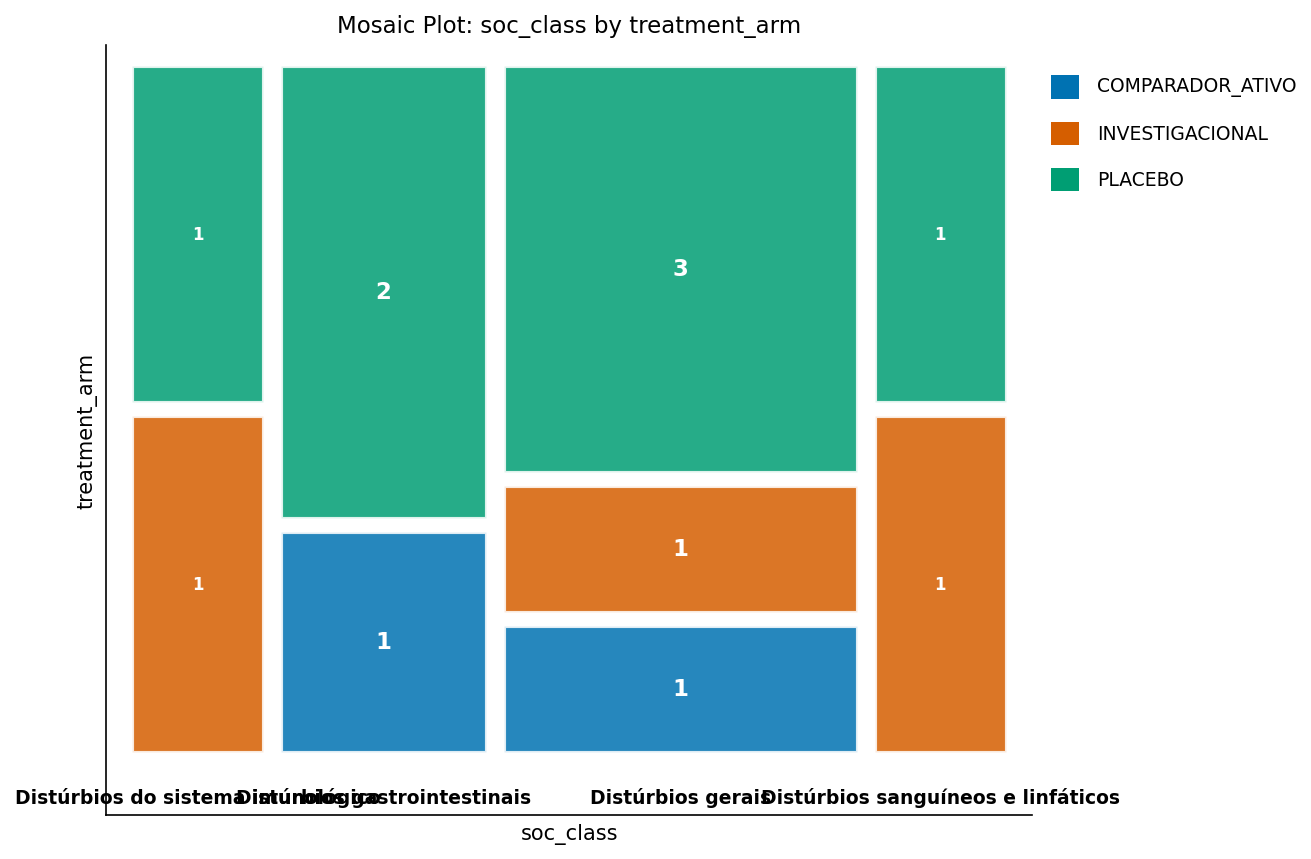

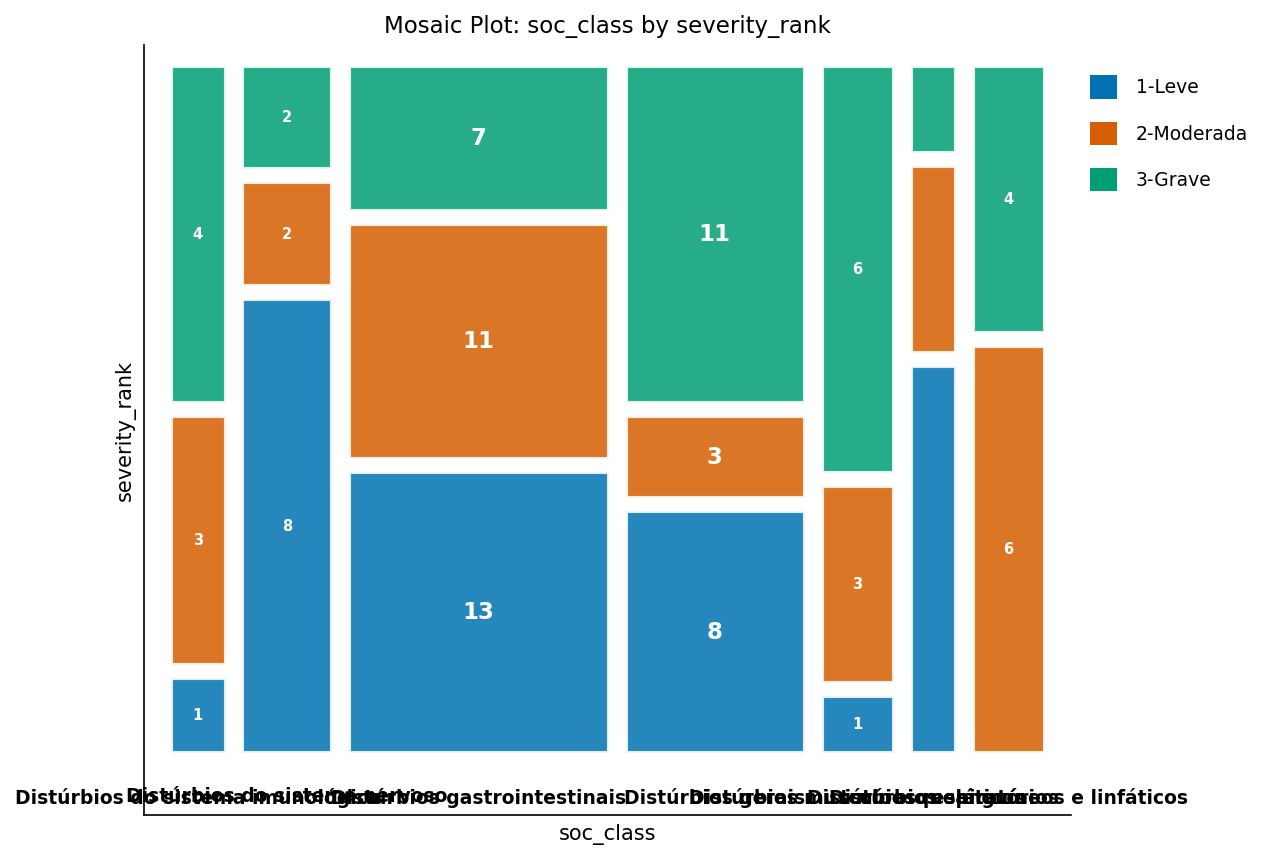

In [7]:
/* --------------------------------------------------------
   Frequência ao nível de SOC por braço de tratamento
   ODS OUTPUT captura os resultados para revisão de sinais
   -------------------------------------------------------- */
ODS SAÍDA onewayfreqs=work.soc_freq_table;

PROCEDIMENTO FREQUÊNCIAS DADOS=work.ae_coded ORDER=FREQUÊNCIAS;
    TABLES soc_class * treatment_arm / nocol nopercent;
    TABLES soc_class * severity_rank / nocol nopercent;
    RÓTULO soc_class = 'Classe de Sistema Orgânico'
          treatment_arm = 'Braço de Tratamento'
          severity_rank = 'Gravidade';
    TÍTULO 'Incidência de EA por Classe de Sistema Orgânico e Braço de Tratamento';
EXECUTAR;

ODS SAÍDA CLOSE;

                                 Eventos Adversos Graves por SOC e Braço de Tratamento                                  

                                                   The FREQ Procedure

Table of Classe de Sistema Orgânico by Braço de Tratamento

Classe de Sistema Orgânico          |COMPARADOR_ATIVO | INVESTIGACIONAL |         PLACEBO |            Total
------------------------------------+-----------------+-----------------+-----------------+-----------------
Distúrbios do sistema imunológico   |               0 |               0 |               1 |                1
------------------------------------+-----------------+-----------------+-----------------+-----------------
Distúrbios gerais                   |               1 |               1 |               1 |                3
------------------------------------+-----------------+-----------------+-----------------+-----------------
Total                               |               1 |               1 |               2 |  


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: PROC FREQ statement used.


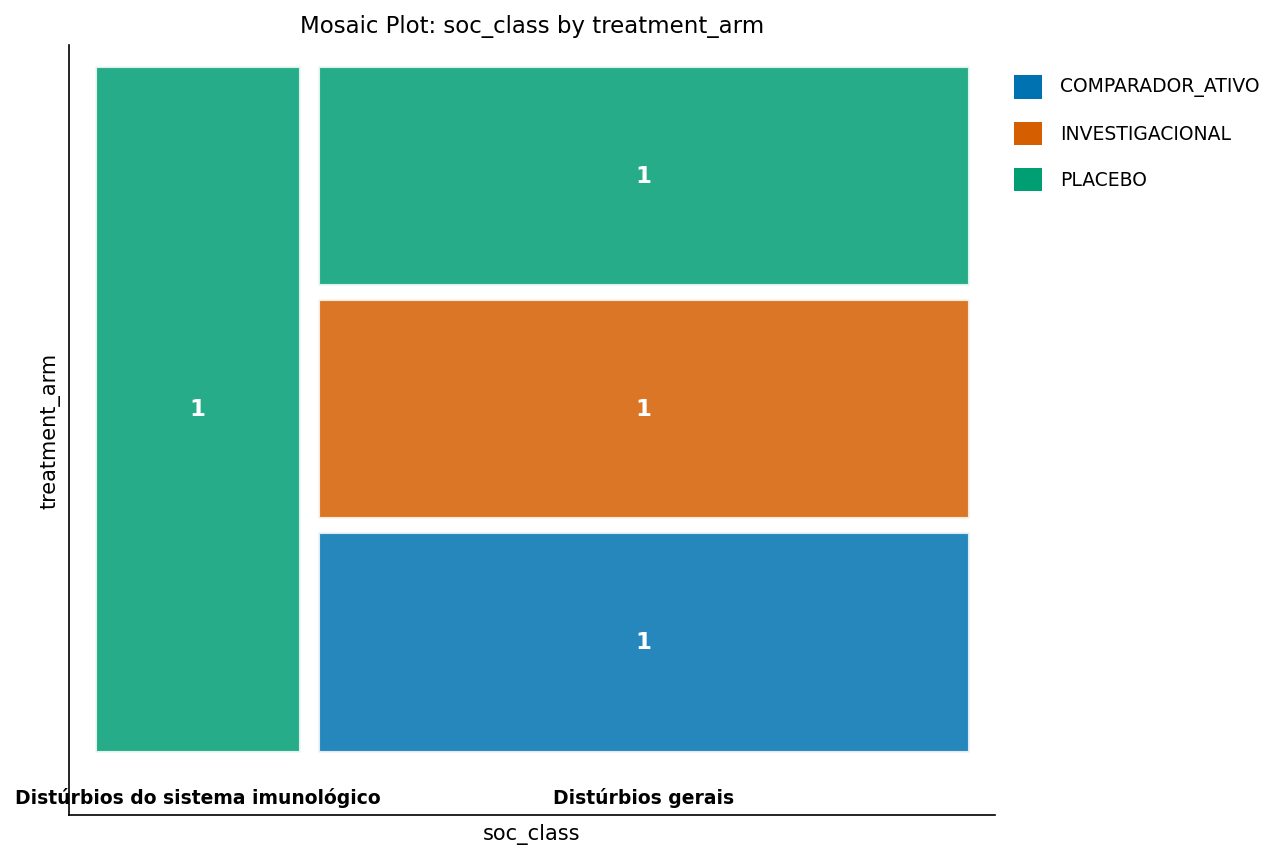

In [8]:
/* --------------------------------------------------------
   Resumo de EA graves por SOC para a narrativa de segurança
   -------------------------------------------------------- */
PROCEDIMENTO FREQUÊNCIAS DADOS=work.ae_coded;
    ONDE aeser = 'Y';
    TABLES soc_class * treatment_arm / nocol nopercent;
    RÓTULO soc_class = 'Classe de Sistema Orgânico'
          treatment_arm = 'Braço de Tratamento';
    TÍTULO 'Eventos Adversos Graves por SOC e Braço de Tratamento';
EXECUTAR;

---

### Interpretação

Um único formato de valor `$pt_to_soc` codificou todos os 100 eventos
adversos a partir de 12 termos preferidos MedDRA verbatim em 7 Classes de
Sistema Orgânico, e esse único formato conduziu cada tabela abaixo sem
recodificar os dados.

Por SOC e gravidade, **Distúrbios gastrointestinais** é a classe mais
frequente, com 31 dos 100 eventos (13 leves, 11 moderados, 7 graves),
seguida por **Distúrbios gerais** com 22 eventos. As demais classes são
menores: Distúrbios do sistema nervoso (12), Distúrbios sanguíneos e
linfáticos (10), Distúrbios musculoesqueléticos (10), Distúrbios do sistema
imunológico (8), e Distúrbios respiratórios (7). Em todos os eventos, a
divisão de gravidade é 35 leves, 30 moderados e 35 graves.

Apenas 4 eventos foram sinalizados como graves (`aeser='Y'`): 3 em
Distúrbios gerais (um por braço) e 1 em Distúrbios do sistema imunológico
(placebo). O cruzamento SOC por braço de tratamento é construído a partir
dos 12 eventos cujo sujeito correspondeu a um registro de randomização,
portanto as contagens por braço são ilustrativas e não têm poder estatístico
para uma comparação entre braços.

A conclusão principal é o mecanismo do FORMAT, não os números sintéticos:
como o mapeamento de termo preferido para SOC reside inteiramente no PROC
FORMAT, a mesma chamada `PUT(aedecod, $pt_to_soc.)` recodifica todo o
conjunto de dados, e atualizar para uma nova versão do dicionário MedDRA
significa editar um único formato em vez de cada relatório. O ODS OUTPUT
capturou as frequências de SOC como `work.soc_freq_table` para revisão de
sinais subsequente.

---

In [9]:
/* --------------------------------------------------------
   Exportar o conjunto de dados de EA codificado por SOC para
   revisão de sinal de segurança. O único formato $pt_to_soc
   preencheu soc_class, então o arquivo exportado está pronto
   para análise a nível de SOC downstream.
   -------------------------------------------------------- */
PROCEDIMENTO EXPORT DADOS=work.ae_coded
    OUTFILE='ae_soc_coded.csv'
    DBMS=csv REPLACE;
EXECUTAR;


NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 100 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido por <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>